#### Neighbor AI-execution regression excluding SOC major group 25 (Education, Training, and Library)
#### By: Peyman Shahidi (robustness build)
#### Created: 2026-07-25

**Motivation.** The DWA-ordering consistency test (`onet_dwaOrdering_consistency.ipynb`) found that the shared
cross-occupation ordering logic in the workflows is concentrated within occupation families and is dominated by
the postsecondary-teacher occupations in SOC major group 25, which share near-identical task statements. If the
Prediction-3 neighbor effects were driven by that family, the local-context interpretation would be weakened.
This notebook re-estimates the Prediction-3 regressions dropping every occupation in SOC major group 25.

**What runs.** Identical pipeline to `onet_neighborAI_E1E2exposureControls.ipynb` (same DWA filters, six
specifications, both samples, delta-method DWA-clustered AME standard errors), with major group 25 removed
before any filtering, so the multi-occupation DWA set and the varying-execution-type DWA set are recomputed on
the restricted universe. Two control sets: the paper's baseline (focal `is_exposed`, E1-only) and the E1/E2
exposure controls for the focal task and its four neighbors. The all-occupation reference series is read from
the stored E1/E2 robustness output (its baseline variant reproduces the paper's point estimates exactly).

**Outputs.** `data/computed_objects/execTypeVaryingDWA_anthropicIndex_excludeSOC25/` (CSVs) and
`writeup/plots/execTypeVaryingDWA_excludeSOC25/` (robustness forests in the GPT-prompt robustness style).

In [1]:
import os, glob
import numpy as np, pandas as pd
import patsy
import statsmodels.formula.api as smf
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

In [2]:
dependent_var = 'is_ai'
TARGET_REGS   = ['prev2_is_ai', 'prev_is_ai', 'next_is_ai', 'next2_is_ai']
EXPO_FOCAL    = 'is_exposed_e12'
EXPO_NBR_REGS = ['prev2_is_exposed_e12', 'prev_is_exposed_e12', 'next_is_exposed_e12', 'next2_is_exposed_e12']
EXCLUDE_MG    = '25-0000'      # Education, Training, and Library Occupations

VAR_LABELS = {'prev2_is_ai': '(t-2) Task AI', 'prev_is_ai': '(t-1) Task AI',
              'next_is_ai': '(t+1) Task AI', 'next2_is_ai': '(t+2) Task AI'}

VARIANTS = {
    'baseline':       ['is_exposed'],               # paper controls (E1-only, focal task)
    'e12_focal_nbrs': [EXPO_FOCAL] + EXPO_NBR_REGS  # + E1|E2 exposure of focal task and neighbors
}
VARIANT_LABEL = {'baseline': 'excl. SOC 25', 'e12_focal_nbrs': 'excl. SOC 25 + E1/E2 controls'}

SPEC_ORDER = ['no_fe_no_dwa', 'major_fe_no_dwa', 'minor_fe_no_dwa', 'no_fe_with_dwa',
              'no_fe_no_dwa_withTaskDWACount', 'no_fe_with_dwa_withTaskDWACount']
star = lambda p: "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

In [3]:
main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
merged_file = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
reference_results_file = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_E1E2exposureControls/ame_results_allVariants.csv"

output_data_path = f"{input_data_path}/computed_objects/execTypeVaryingDWA_anthropicIndex_excludeSOC25"
output_plot_path = f"{main_folder_path}/writeup/plots/execTypeVaryingDWA_excludeSOC25"
for p in [output_data_path, output_plot_path]: os.makedirs(p, exist_ok=True)

## DWA helper objects, recomputed on the universe without SOC major group 25

The single-DWA task list and the GPT-identified similar-task list are task-level objects and carry over; the
varying-execution-type DWA set is recomputed on the restricted data (occupation counts and manual shares change
once the education family is removed). The DWAs-in-more-than-one-occupation filter is applied inside the sample
construction and therefore also reflects the restricted universe.

In [4]:
dwa_csv_files = glob.glob(os.path.join(f"{input_data_path}/computed_objects/similar_dwa_tasks/similarTasks", "*.csv"))
dwa_dfs = [pd.read_csv(f) for f in dwa_csv_files]
df_all = pd.concat([d for d in dwa_dfs if len(d) > 1], ignore_index=True)
repetitive_dwa_task_ids = df_all['Task ID'].unique().tolist()

dwa_task_mapping = pd.read_csv(f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv")
dwa_task_counts = dwa_task_mapping.groupby('Task ID')['DWA ID'].nunique().reset_index(name='n')
unique_task_dwa_mapping = dwa_task_counts[dwa_task_counts['n'] == 1]['Task ID'].tolist()

_md = pd.read_csv(merged_file)
_md = _md[_md['Major_Group_Code'] != EXCLUDE_MG]           # recompute on the restricted universe
_md['is_manual'] = _md['label'] == 'Manual'
_md = _md.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
_dg = _md.groupby(['DWA ID', 'DWA Title']).agg(no=('O*NET-SOC Code', 'nunique'), fm=('is_manual', 'mean')).reset_index()
dwas_varying_exec_types_ids = _dg[(_dg['no'] > 1) & (_dg['fm'] > 0) & (_dg['fm'] < 1)]['DWA ID'].unique().tolist()
print(f"single-DWA tasks: {len(unique_task_dwa_mapping):,} | DWAs with varying exec types (excl. SOC 25): {len(dwas_varying_exec_types_ids):,}")

single-DWA tasks: 13,748 | DWAs with varying exec types (excl. SOC 25): 773


## Build the analytic samples without SOC major group 25

In [5]:
def build_dataset():
    """Baseline analytic samples of the Prediction-3 pipeline, excluding SOC major group 25, with the
    E1/E2 exposure flags for the focal task and its neighbors. Returns (full_eligible_df, gpt_filtered_df)."""
    d = pd.read_csv(merged_file)
    d = d[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title', 'Task Position',
           'Major_Group_Code', 'Minor_Group_Code', 'gpt4_exposure', 'human_labels', 'label']].copy()
    d = d[d['Major_Group_Code'] != EXCLUDE_MG].reset_index(drop=True)      # drop the education family
    d['is_ai'] = d['label'].isin(['Augmentation', 'Automation']).astype(int)
    d['is_exposed'] = d['human_labels'].isin(['E1']).astype(int)
    d['is_exposed_e12'] = d['human_labels'].isin(['E1', 'E2']).astype(int)
    n = d.groupby('O*NET-SOC Code')['Task ID'].nunique().reset_index().rename(columns={'Task ID': 'num_tasks'})
    d = d.merge(n, on='O*NET-SOC Code', how='left')
    d['Task Position'] = pd.to_numeric(d['Task Position'], errors='coerce')
    d = d.sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
    for src in ['is_ai', 'is_exposed_e12']:
        g = d.groupby('O*NET-SOC Code')[src]
        d[f'prev_{src}'] = g.shift(1); d[f'prev2_{src}'] = g.shift(2)
        d[f'next_{src}'] = g.shift(-1); d[f'next2_{src}'] = g.shift(-2)
    nb_ai = ['prev_is_ai', 'prev2_is_ai', 'next_is_ai', 'next2_is_ai']
    d = d.dropna(subset=nb_ai).reset_index(drop=True)
    for c in nb_ai + EXPO_NBR_REGS: d[c] = d[c].astype(int)
    d = d.merge(dwa_task_mapping, on=['Task ID', 'Task Title', 'O*NET-SOC Code', 'Occupation Title'], how='left')
    d = d[d['Task ID'].isin(unique_task_dwa_mapping)].reset_index(drop=True)
    d = d.drop_duplicates(subset=['O*NET-SOC Code', 'Task ID']).reset_index(drop=True)
    d = d[~d['DWA ID'].isna()].reset_index(drop=True)
    occ = d.groupby('DWA ID')['O*NET-SOC Code'].nunique(); keep = occ[occ > 1].index
    d = d[d['DWA ID'].isin(keep)].reset_index(drop=True)
    cnt = d.groupby(['DWA ID', 'O*NET-SOC Code'])['Task ID'].nunique().reset_index(name='num_tasks_in_dwa_within_occupation')
    d = d.merge(cnt, on=['DWA ID', 'O*NET-SOC Code'], how='left')
    filt = d[(d['DWA ID'].isin(dwas_varying_exec_types_ids) & d['Task ID'].isin(repetitive_dwa_task_ids))].reset_index(drop=True)
    for x in (d, filt):
        sc = x.select_dtypes(include=['string']).columns; x[sc] = x[sc].astype(object)
    return d, filt

ds_full, ds_filt = build_dataset()
print(f"full-eligible (excl. SOC 25): {len(ds_full):,} task-rows across {ds_full['DWA ID'].nunique():,} DWAs "
      f"(all occupations: 10,708 / 1,748)")
print(f"GPT-filtered  (excl. SOC 25): {len(ds_filt):,} task-rows across {ds_filt['DWA ID'].nunique():,} DWAs "
      f"(all occupations: 3,689)")

full-eligible (excl. SOC 25): 9,755 task-rows across 1,674 DWAs (all occupations: 10,708 / 1,748)
GPT-filtered  (excl. SOC 25): 3,198 task-rows across 670 DWAs (all occupations: 3,689)


## Estimation machinery (identical to the E1/E2 robustness notebook)

In [6]:
def _ame_delta(res, df, terms):
    """Discrete-change AMEs with delta-method SEs using the fit's DWA-clustered covariance."""
    di = res.model.data.design_info
    beta = np.asarray(res.params); V = np.asarray(res.cov_params())
    out = {}
    for v in terms:
        d1 = df.copy(); d0 = df.copy(); d1[v] = 1; d0[v] = 0
        X1 = np.asarray(patsy.build_design_matrices([di], d1)[0])
        X0 = np.asarray(patsy.build_design_matrices([di], d0)[0])
        p1 = 1.0 / (1.0 + np.exp(-(X1 @ beta))); p0 = 1.0 / (1.0 + np.exp(-(X0 @ beta)))
        ame = float(np.mean(p1 - p0))
        grad = ((p1 * (1 - p1))[:, None] * X1 - (p0 * (1 - p0))[:, None] * X0).mean(axis=0)
        se = float(np.sqrt(grad @ V @ grad))
        pval = float(2 * norm.sf(abs(ame / se))) if se > 0 else np.nan
        out[v] = (ame, se, pval)
    return out


def run_variant(df, dataset_name, variant_name, controls, dep=dependent_var):
    """Fit the six baseline specifications with the variant's controls; return long-format AME rows."""
    df = df.copy(); df['DWA_ID'] = df['DWA ID']
    ame_terms = TARGET_REGS + controls
    base = f'{dep} ~ ' + ' + '.join(TARGET_REGS + controls) + ' + num_tasks'
    df_dwa = df.groupby('DWA_ID').filter(lambda g: g[dep].nunique() > 1)
    specs = [
        ('no_fe_no_dwa',                    base,                                                       df,     'DWA ID', 'None',  False, False),
        ('major_fe_no_dwa',                 base + ' + C(Major_Group_Code)',
            df.groupby('Major_Group_Code').filter(lambda g: g[dep].nunique() > 1),                      'DWA ID', 'Major', False, False),
        ('minor_fe_no_dwa',                 base + ' + C(Minor_Group_Code)',
            df.groupby('Minor_Group_Code').filter(lambda g: g[dep].nunique() > 1),                      'DWA ID', 'Minor', False, False),
        ('no_fe_with_dwa',                  base + ' + C(DWA_ID)',                                      df_dwa, 'DWA_ID', 'None',  True,  False),
        ('no_fe_no_dwa_withTaskDWACount',   base + ' + num_tasks_in_dwa_within_occupation',             df_dwa, 'DWA_ID', 'None',  False, True),
        ('no_fe_with_dwa_withTaskDWACount', base + ' + C(DWA_ID) + num_tasks_in_dwa_within_occupation', df_dwa, 'DWA_ID', 'None',  True,  True),
    ]
    rows = []
    for name, formula, data, cluster, fe_label, dwa_fe, dwacount in specs:
        try:
            try:
                res = smf.logit(formula, data=data).fit(disp=False, cov_type='cluster',
                                                        cov_kwds={'groups': data[cluster], 'use_correction': True})
            except Exception:
                res = smf.logit(formula, data=data).fit(disp=False, method='bfgs', maxiter=500, cov_type='cluster',
                                                        cov_kwds={'groups': data[cluster], 'use_correction': True})
            ames = _ame_delta(res, data, ame_terms)
            for t in ame_terms:
                a, s, p = ames[t]
                rows.append({'dataset': dataset_name, 'variant': variant_name, 'model': name,
                             'fe_label': fe_label, 'dwa_fe': dwa_fe, 'dwa_task_count_control': dwacount,
                             'nobs': int(res.nobs), 'r2_pseudo': float(res.prsquared),
                             'term': t, 'ame_coef': a, 'ame_se': s, 'p_value': p,
                             'coef': float(res.params[t]), 'coef_p_clustered': float(res.pvalues[t])})
        except Exception as e:
            print(f"  [{dataset_name}|{variant_name}|{name}] failed: {e}")
    return pd.DataFrame(rows)

## Run: 2 samples x 2 control sets x 6 specifications

In [7]:
all_rows = []
for ds_name, ds in [('full_eligible', ds_full), ('gpt_filtered', ds_filt)]:
    for var_name, controls in VARIANTS.items():
        print(f">>> {ds_name} | {var_name}")
        all_rows.append(run_variant(ds, ds_name, var_name, controls))
results = pd.concat(all_rows, ignore_index=True)
results.to_csv(f"{output_data_path}/ame_results_excludeSOC25.csv", index=False)
print(f"\nSaved {len(results):,} AME rows -> {output_data_path}/ame_results_excludeSOC25.csv")

>>> full_eligible | baseline


>>> full_eligible | e12_focal_nbrs


>>> gpt_filtered | baseline


>>> gpt_filtered | e12_focal_nbrs



Saved 168 AME rows -> ../data/computed_objects/execTypeVaryingDWA_anthropicIndex_excludeSOC25/ame_results_excludeSOC25.csv


## Comparison against the all-occupation estimates

The reference series is the `baseline` variant of the stored E1/E2 robustness output, whose point estimates
match the paper's to numerical precision. Stars use the delta-method DWA-clustered AME test.

In [8]:
reference = pd.read_csv(reference_results_file)
ref = reference[reference['variant'] == 'baseline'].copy()
ref['series'] = 'all_occs'
new = results.copy(); new['series'] = new['variant'].map({'baseline': 'excl25', 'e12_focal_nbrs': 'excl25_e12'})
plotdf = pd.concat([ref, new], ignore_index=True)
SERIES_ORDER = ['all_occs', 'excl25', 'excl25_e12']
SERIES_LABEL = {'all_occs': 'All occupations (paper)', 'excl25': 'Excl. SOC 25',
                'excl25_e12': 'Excl. SOC 25 + E1/E2 exposure controls'}

def compact(ds_name):
    print(f"\n=== {ds_name}: immediate neighbors (t-1, t+1) ===")
    print(f"{'spec':<34}{'series':<42}{'(t-1) AI':>12}{'(t+1) AI':>12}{'N':>9}")
    for sp in SPEC_ORDER:
        for s in SERIES_ORDER:
            sub = plotdf[(plotdf.dataset == ds_name) & (plotdf.series == s) & (plotdf.model == sp)]
            if not len(sub): continue
            def cell(t):
                x = sub[sub.term == t]
                return f"{x['ame_coef'].iloc[0]:.3f}{star(x['p_value'].iloc[0])}" if len(x) else '.'
            print(f"{sp:<34}{SERIES_LABEL[s]:<42}{cell('prev_is_ai'):>12}{cell('next_is_ai'):>12}"
                  f"{int(sub['nobs'].iloc[0]):>9,}")

compact('full_eligible')
compact('gpt_filtered')

def wide_table(ds_name):
    rows = []
    for term in TARGET_REGS:
        r = {'neighbor': VAR_LABELS[term]}
        for sp in SPEC_ORDER:
            for s in SERIES_ORDER:
                x = plotdf[(plotdf.dataset == ds_name) & (plotdf.series == s) &
                           (plotdf.model == sp) & (plotdf.term == term)]
                r[f'{sp}|{s}'] = f"{x['ame_coef'].iloc[0]:.3f}{star(x['p_value'].iloc[0])}" if len(x) else '.'
        rows.append(r)
    nrow = {'neighbor': 'N (obs)'}
    for sp in SPEC_ORDER:
        for s in SERIES_ORDER:
            x = plotdf[(plotdf.dataset == ds_name) & (plotdf.series == s) & (plotdf.model == sp)]
            nrow[f'{sp}|{s}'] = f"{int(x['nobs'].iloc[0]):,}" if len(x) else '.'
    rows.append(nrow)
    return pd.DataFrame(rows)

for ds_name, fname in [('full_eligible', 'ame_comparison_full_eligible.csv'),
                       ('gpt_filtered', 'ame_comparison_gpt_filtered.csv')]:
    wide_table(ds_name).to_csv(f"{output_data_path}/{fname}", index=False)
    print(f"Saved {fname}")


=== full_eligible: immediate neighbors (t-1, t+1) ===
spec                              series                                        (t-1) AI    (t+1) AI        N
no_fe_no_dwa                      All occupations (paper)                       0.124***    0.117***   10,708
no_fe_no_dwa                      Excl. SOC 25                                  0.101***    0.114***    9,755
no_fe_no_dwa                      Excl. SOC 25 + E1/E2 exposure controls        0.067***    0.079***    9,755
major_fe_no_dwa                   All occupations (paper)                       0.061***    0.057***   10,708
major_fe_no_dwa                   Excl. SOC 25                                  0.059***    0.070***    9,755
major_fe_no_dwa                   Excl. SOC 25 + E1/E2 exposure controls        0.051***    0.062***    9,755
minor_fe_no_dwa                   All occupations (paper)                       0.051***    0.048***    9,861
minor_fe_no_dwa                   Excl. SOC 25                   

## Robustness forests (GPT-prompt robustness style)

Red (purple in the DWA-FE spec) marks the paper's all-occupation estimate; the two restricted-sample series
follow in the specification's series color. Whiskers are 90% CIs from the delta-method DWA-clustered SEs.

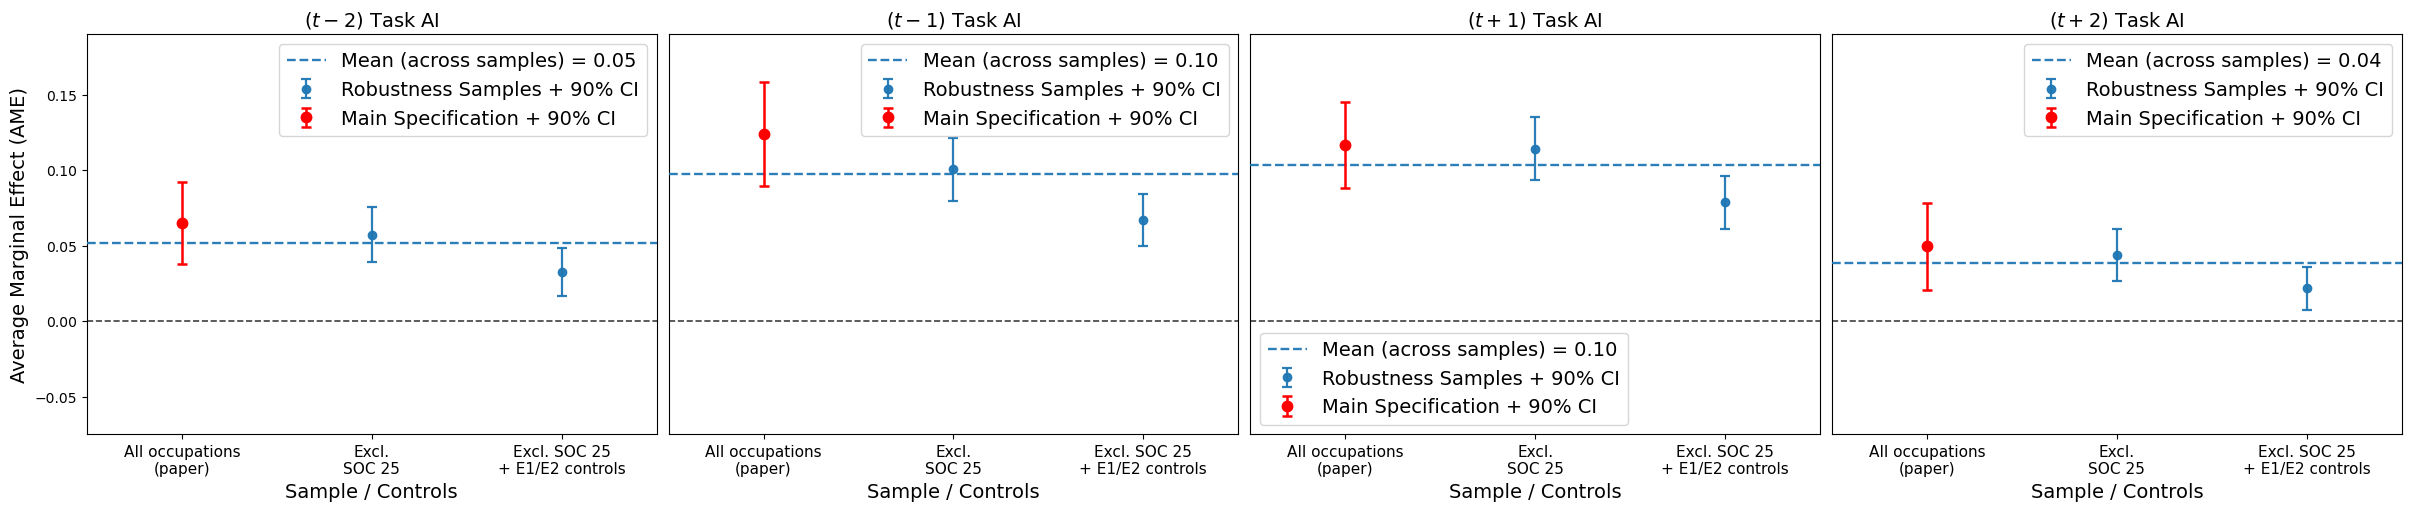

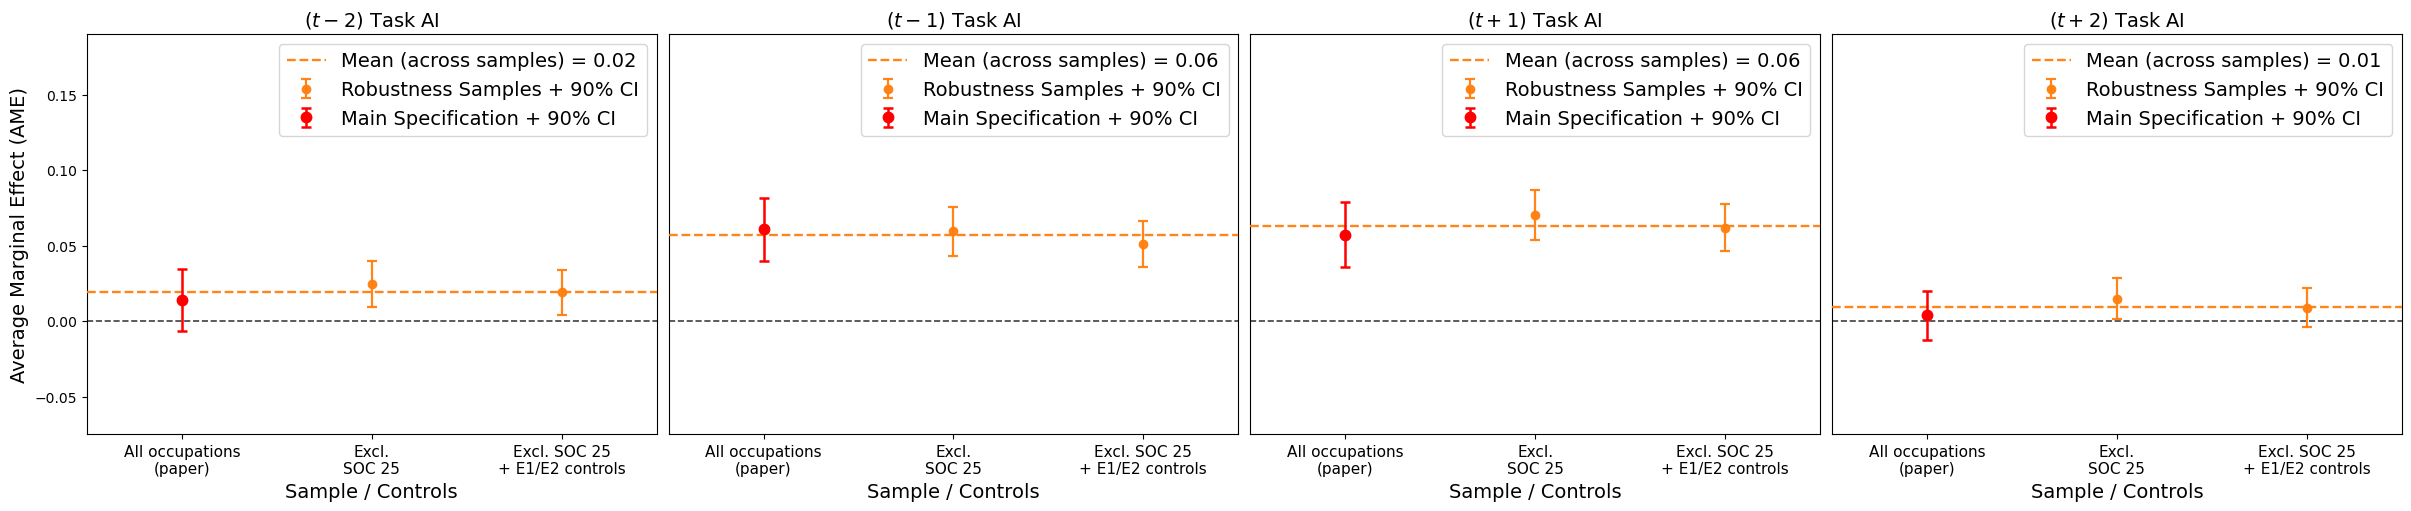

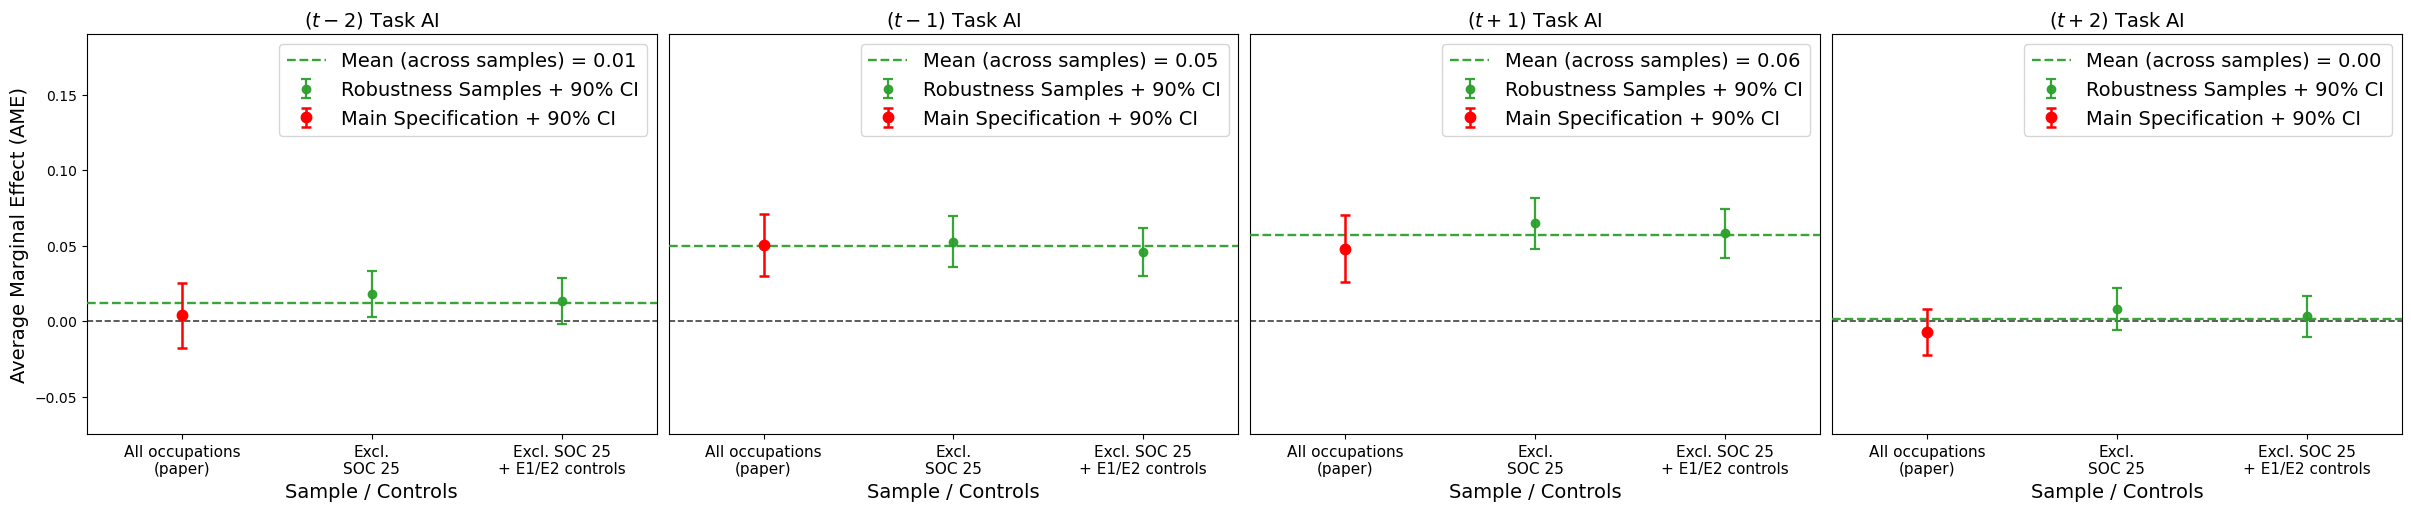

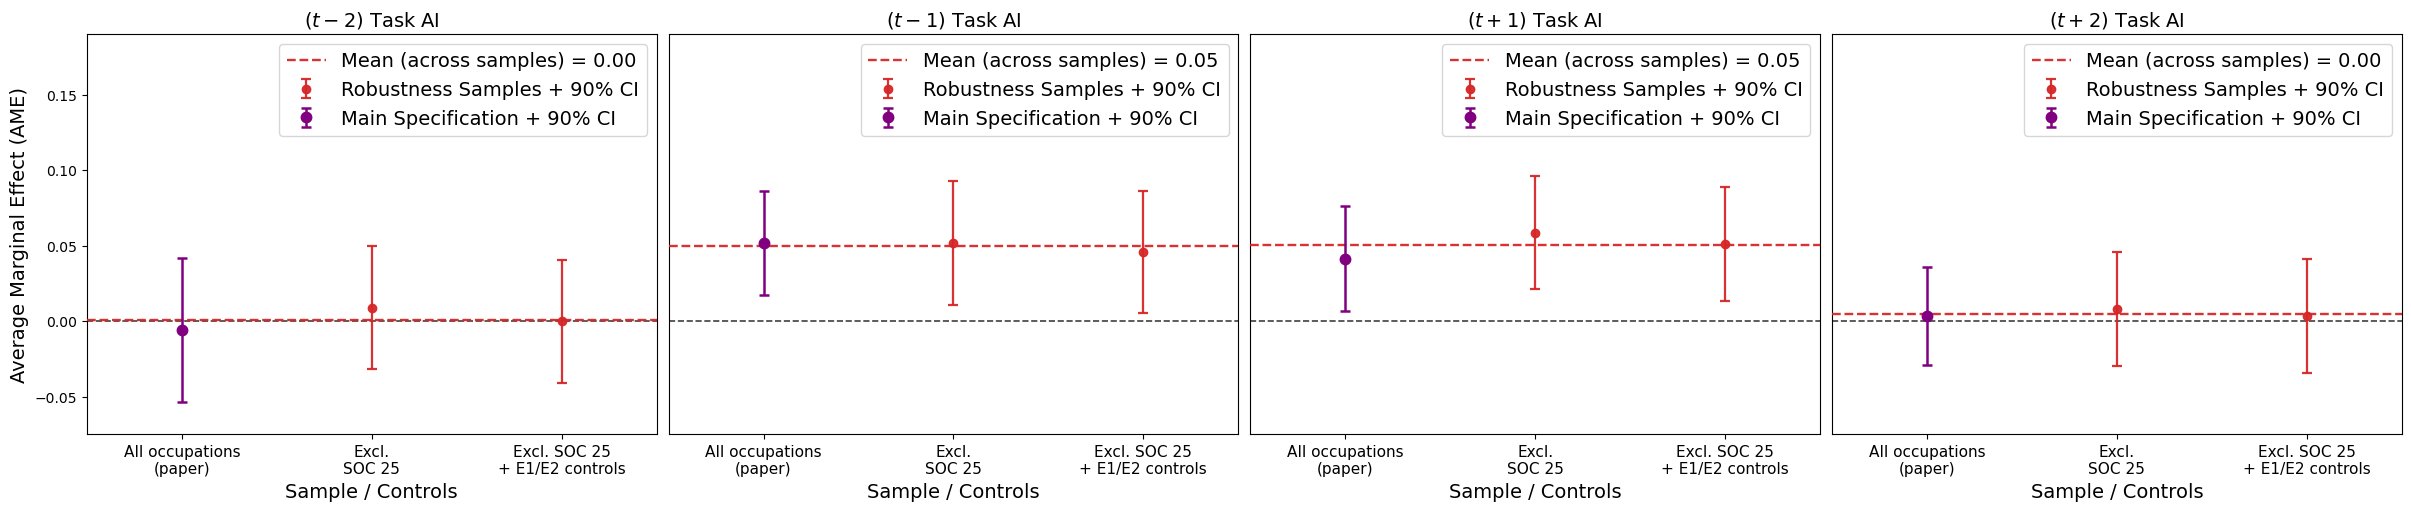

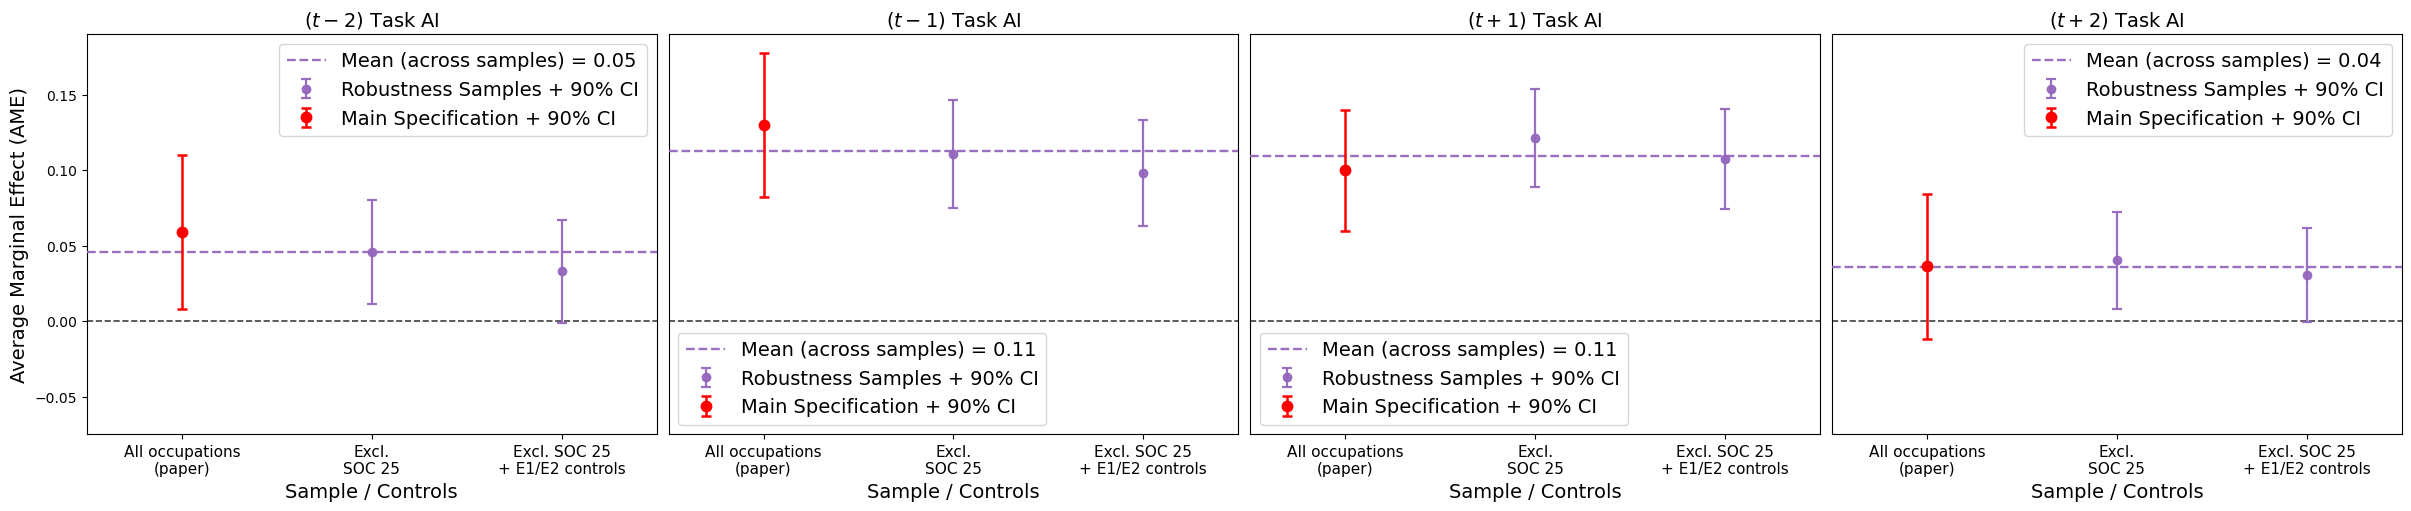

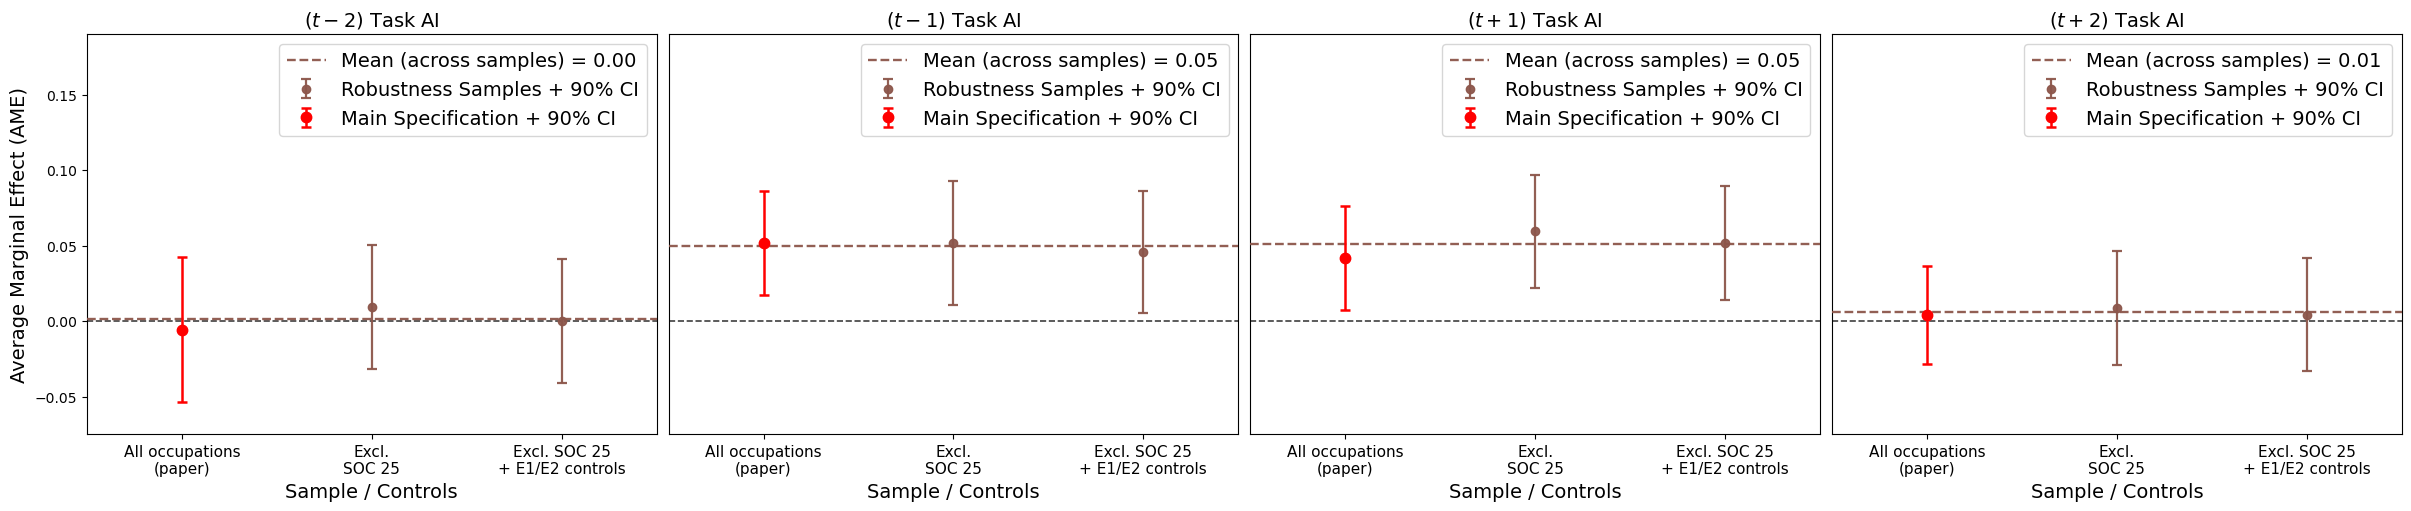

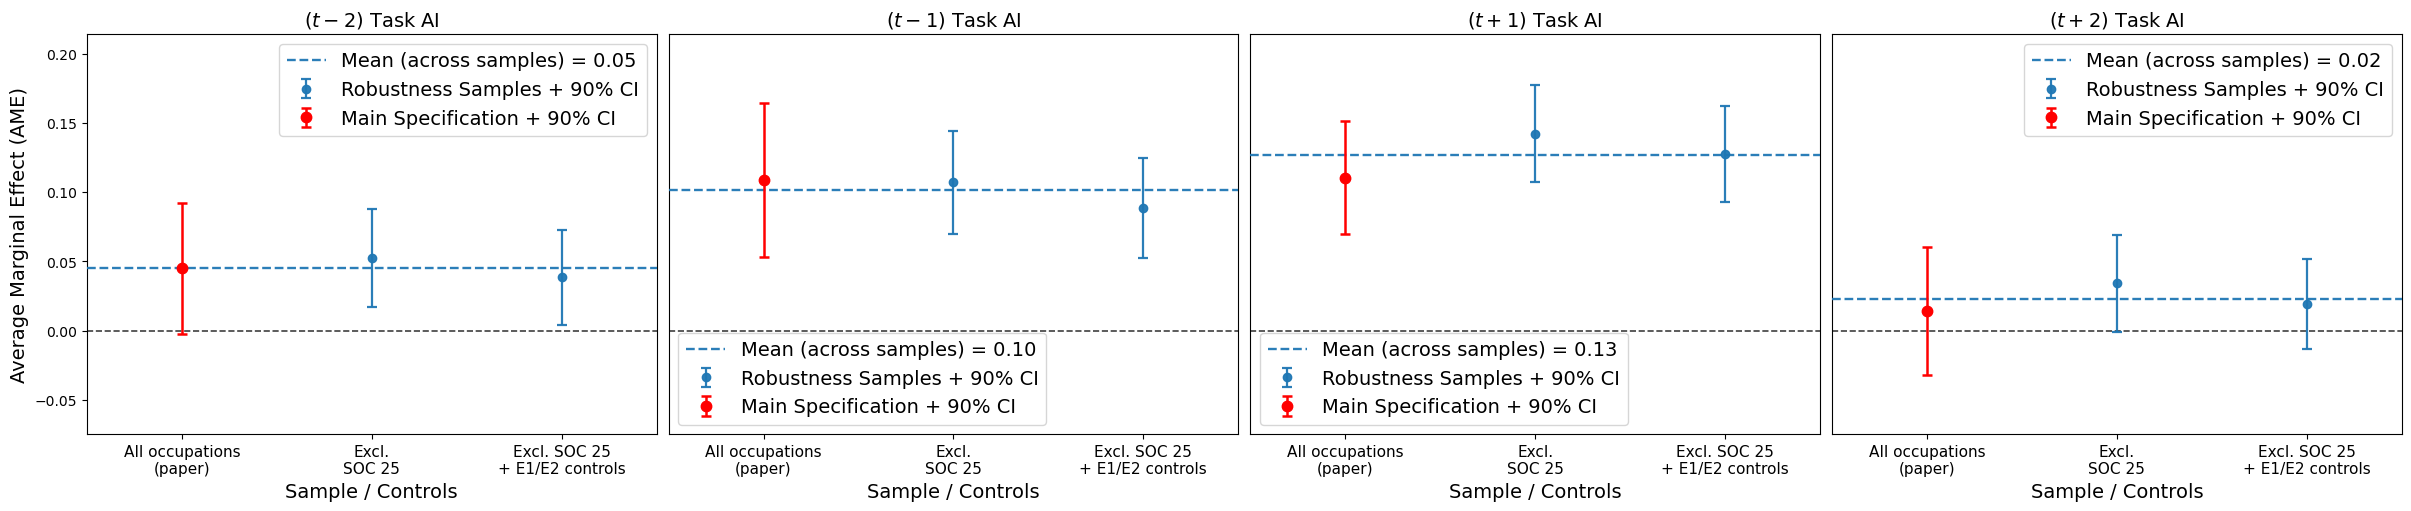

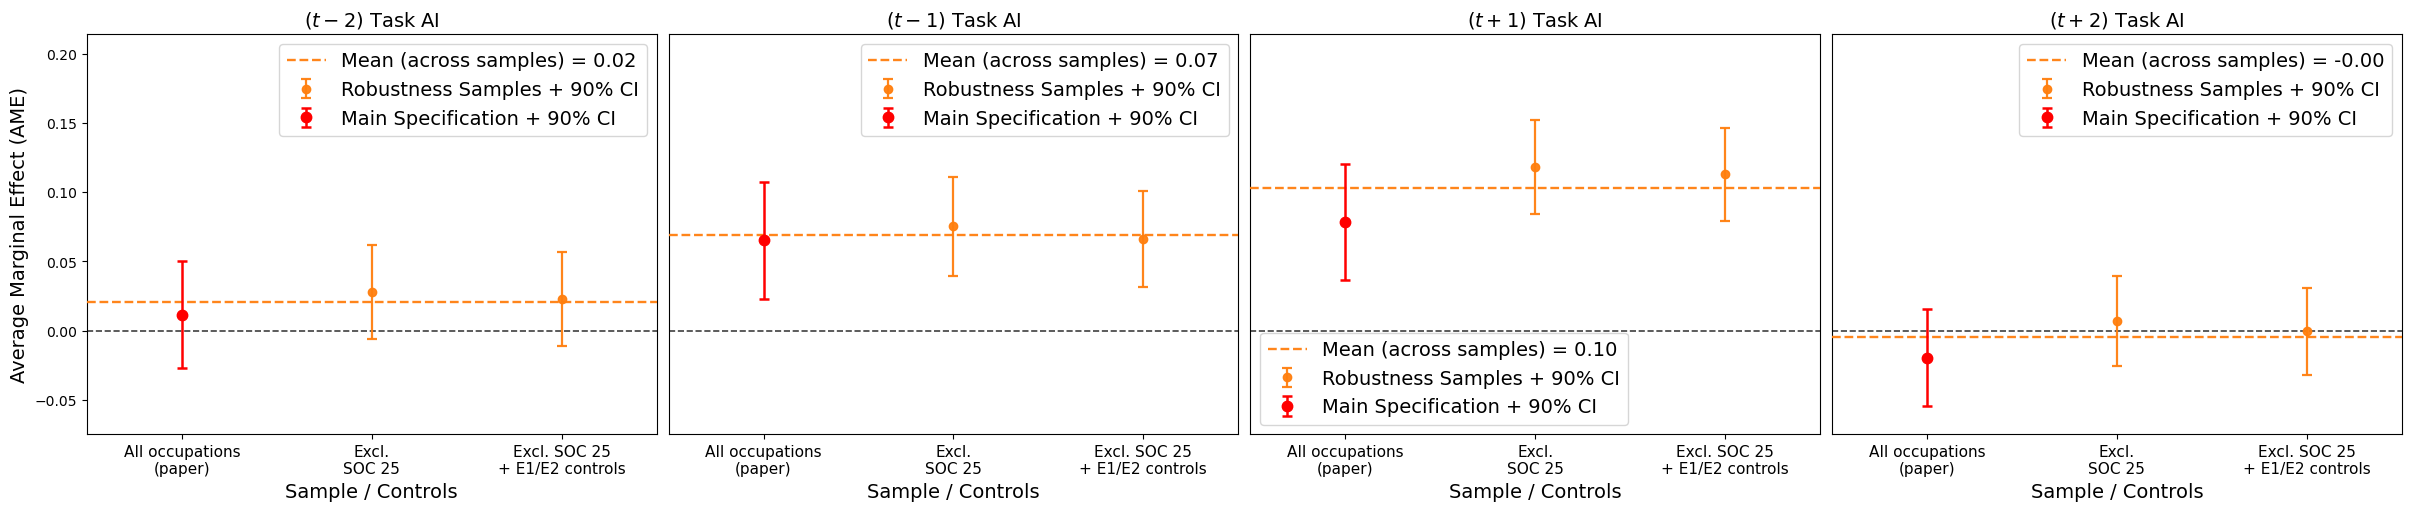

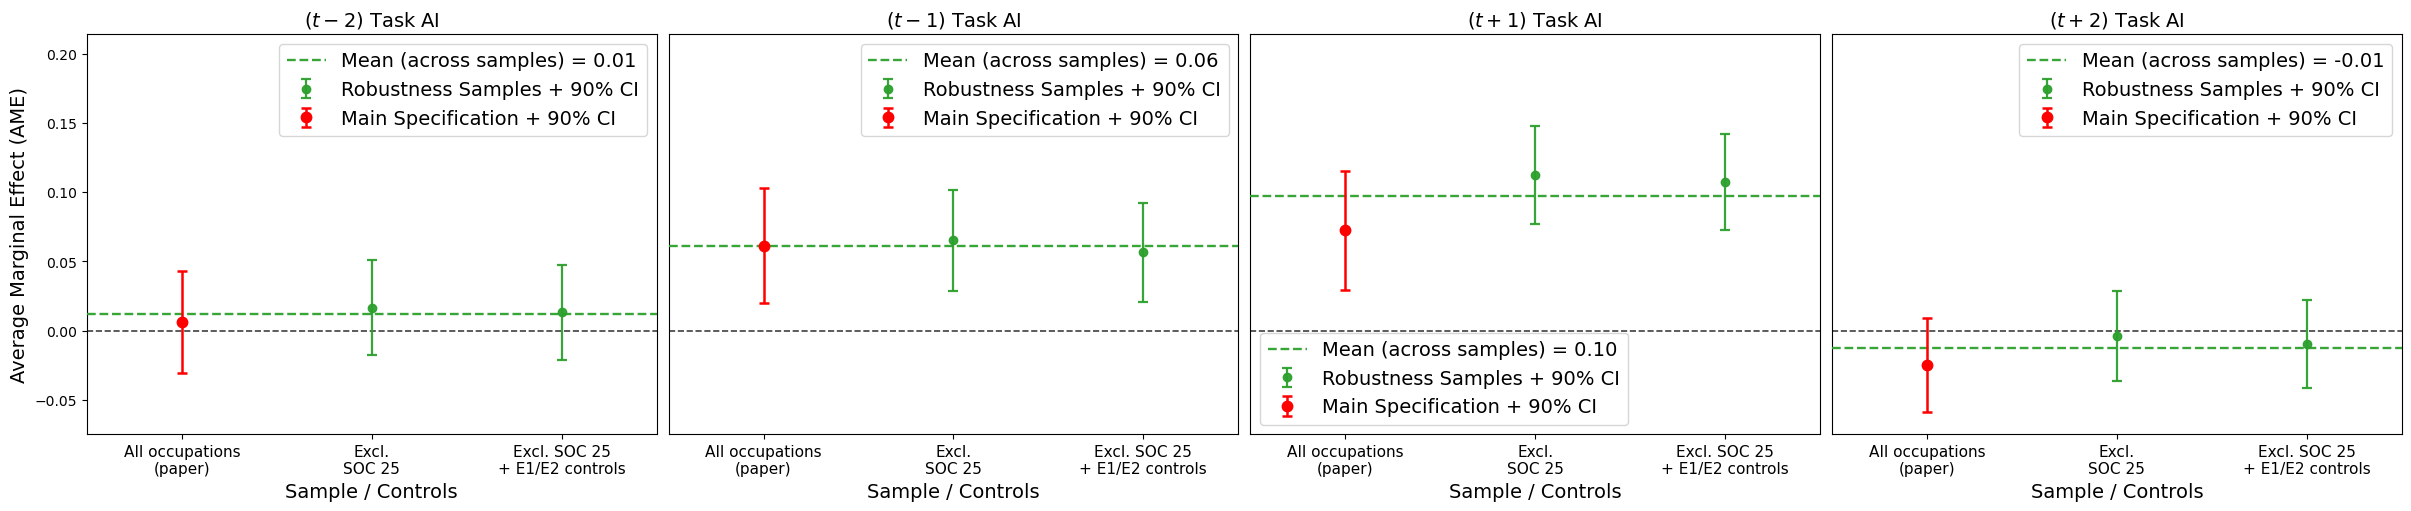

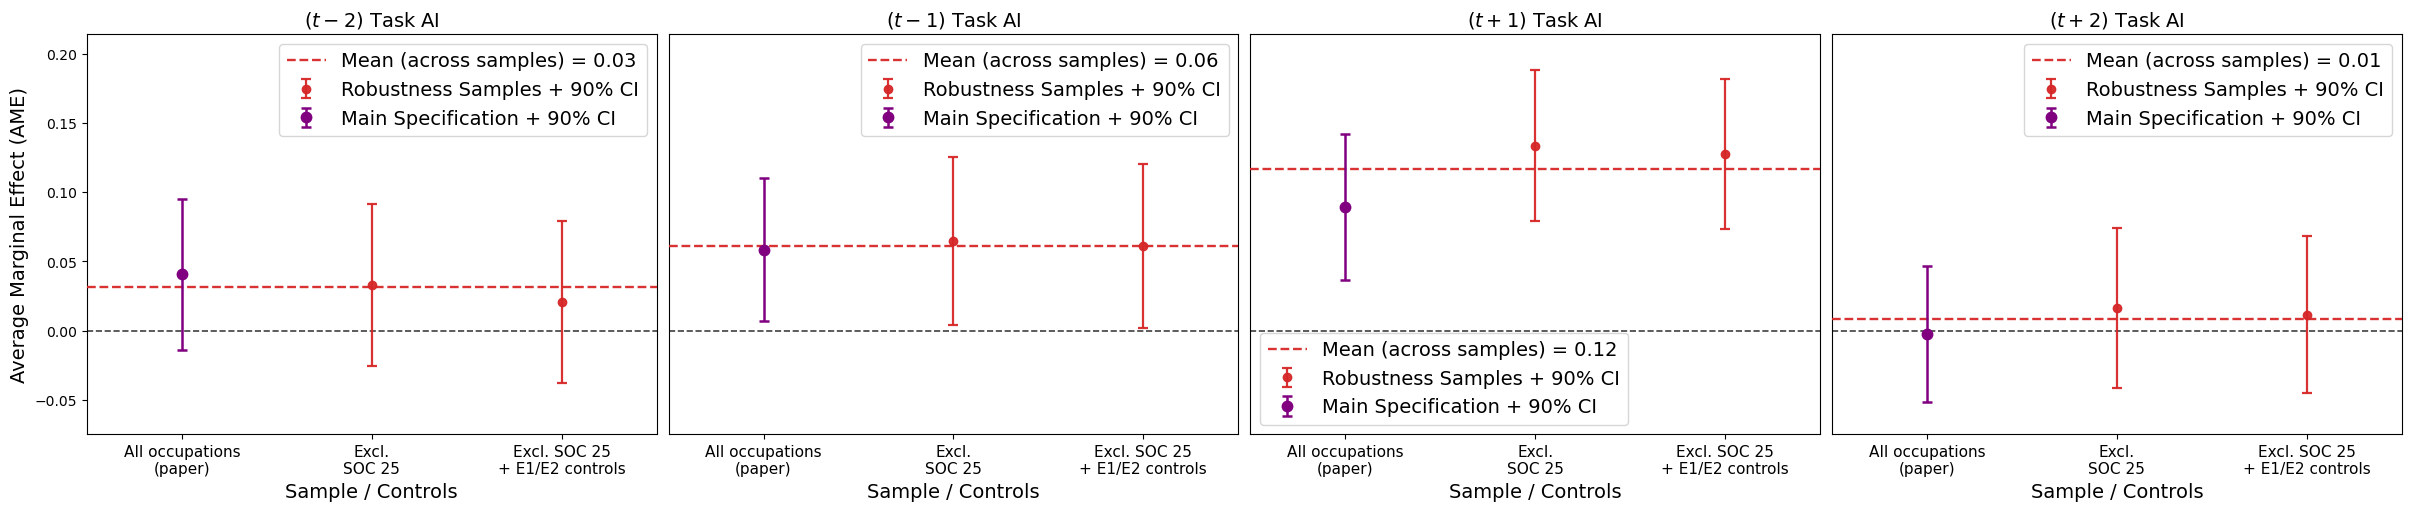

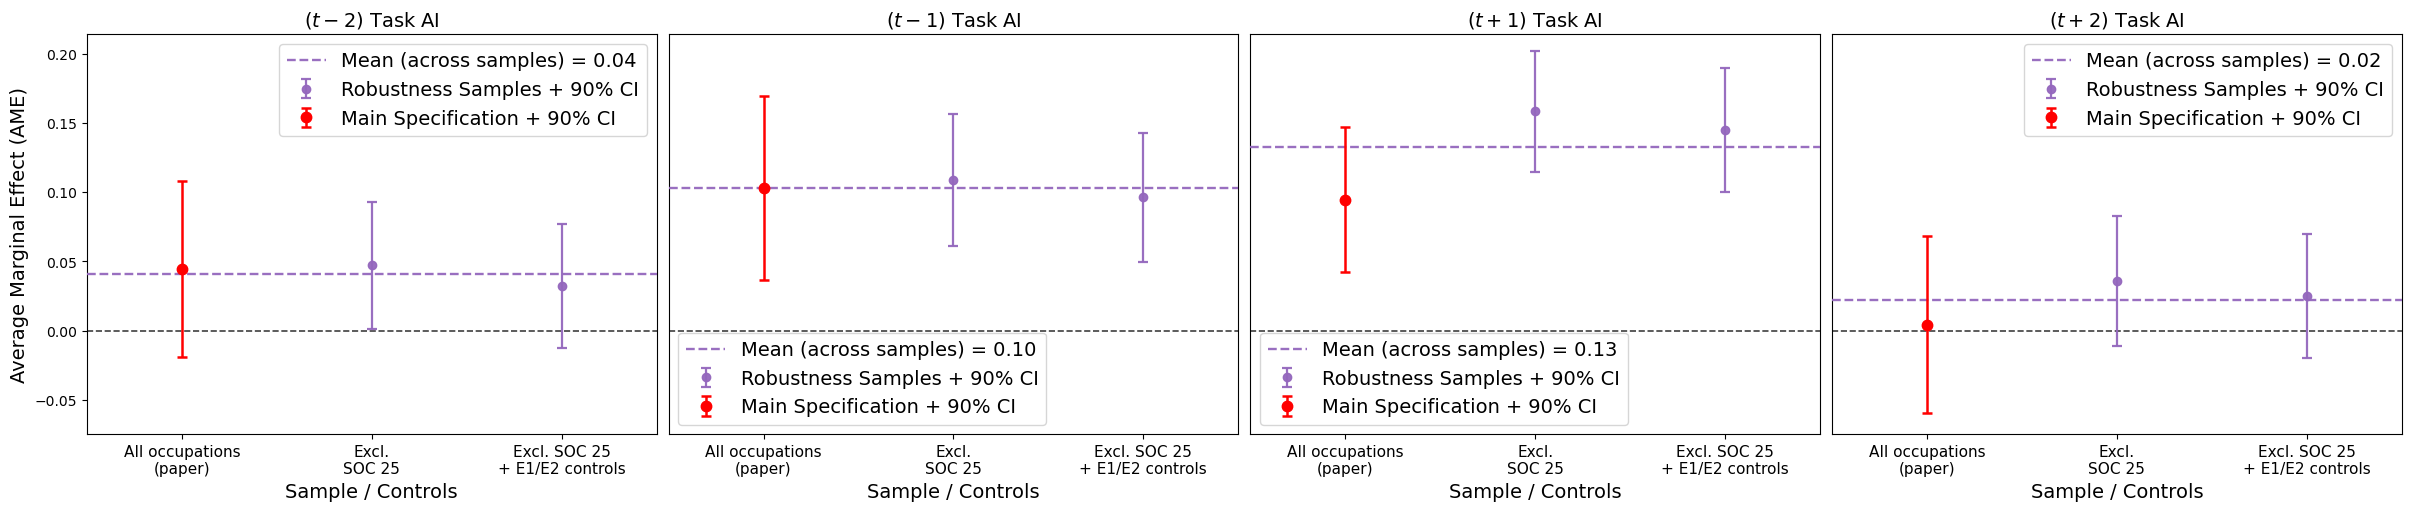

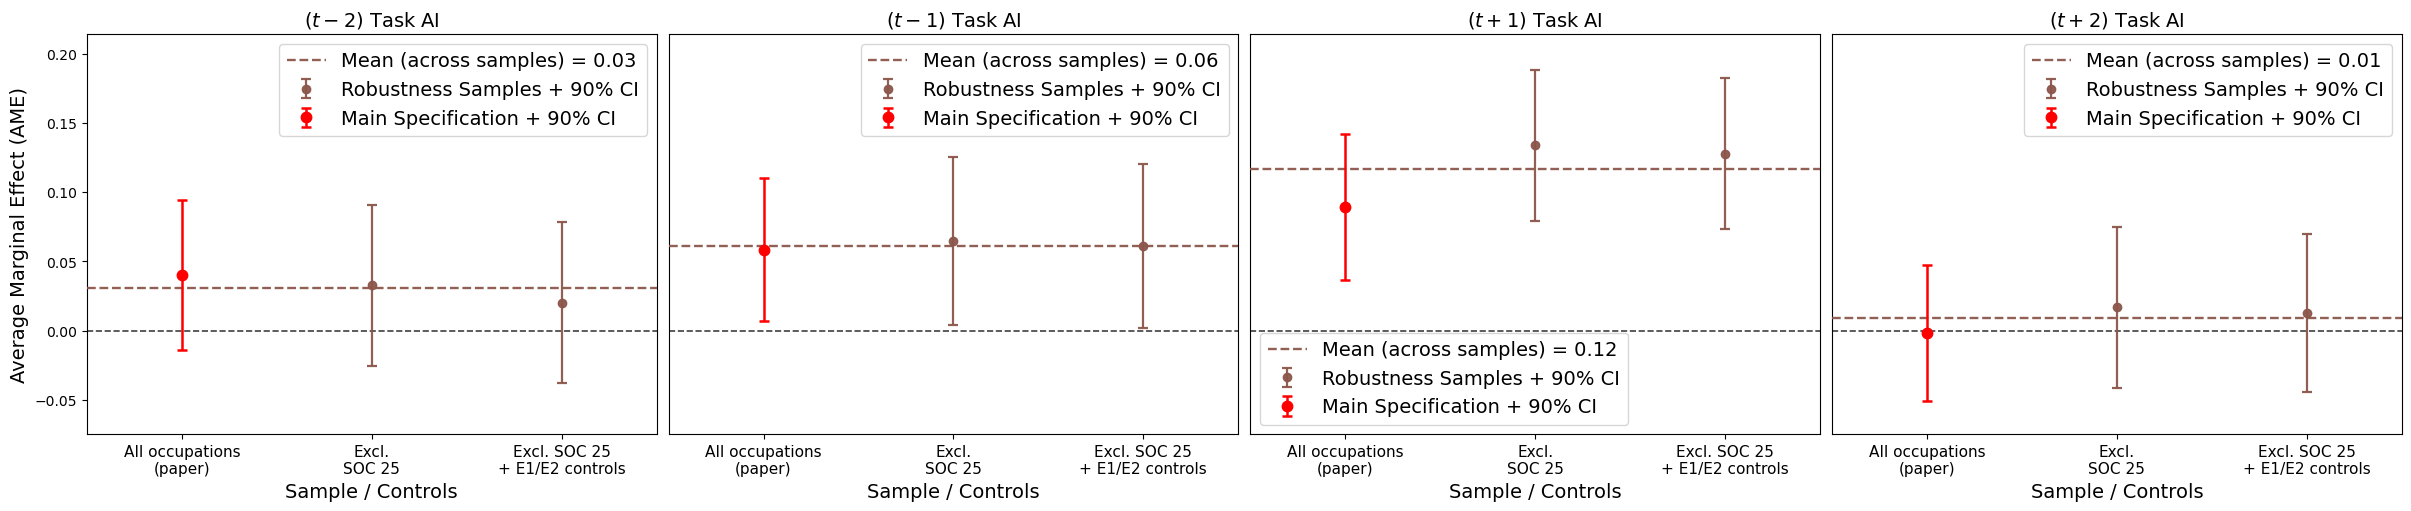

Saved 12 figures to ../writeup/plots/execTypeVaryingDWA_excludeSOC25


In [9]:
PLOT_TITLES = ['($t-2$) Task AI', '($t-1$) Task AI', '($t+1$) Task AI', '($t+2$) Task AI']
SPEC2COLOR = {spec: plt.cm.tab10(i % 10) for i, spec in enumerate(SPEC_ORDER)}
SERIES_X = {'all_occs': 0, 'excl25': 1, 'excl25_e12': 2}
X_TICKLABELS = ['All occupations\n(paper)', 'Excl.\nSOC 25', 'Excl. SOC 25\n+ E1/E2 controls']
Z90 = 1.645

for ds_name, suffix in [('full_eligible', ''), ('gpt_filtered', '_gptFiltered')]:
    dfp = plotdf[(plotdf.dataset == ds_name) & (plotdf.term.isin(TARGET_REGS))].copy()
    dfp['x'] = dfp['series'].map(SERIES_X)
    dfp['ci_low'] = dfp['ame_coef'] - Z90 * dfp['ame_se']
    dfp['ci_high'] = dfp['ame_coef'] + Z90 * dfp['ame_se']
    ylims = (min(-0.075, dfp['ci_low'].min() - 0.012), max(0.19, dfp['ci_high'].max() + 0.012))
    for si, spec in enumerate(SPEC_ORDER):
        spec_color = SPEC2COLOR[spec]
        main_color = 'purple' if si == 3 else 'red'   # the 4th spec's series color is red
        fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)
        for j, (reg, title) in enumerate(zip(TARGET_REGS, PLOT_TITLES)):
            ax = axes[j]
            sub = dfp[(dfp['model'] == spec) & (dfp['term'] == reg)].sort_values('x')
            ax.axhline(0, color='0.25', lw=1.2, ls='--', zorder=0)
            x = sub['x'].astype(float).values; y = sub['ame_coef'].astype(float).values
            lo = sub['ci_low'].astype(float).values; hi = sub['ci_high'].astype(float).values
            yerr = np.vstack([y - lo, hi - y]); mask0 = (x == 0); m = ~mask0
            if m.any():
                ax.errorbar(x[m], y[m], yerr=yerr[:, m], fmt='o', ms=6, color=spec_color, ecolor=spec_color,
                            elinewidth=1.6, capsize=3.5, capthick=1.6, alpha=0.95, zorder=3,
                            label='Robustness Samples + 90% CI')
            if mask0.any():
                ax.errorbar(x[mask0], y[mask0], yerr=yerr[:, mask0], fmt='o', ms=7.5, color=main_color,
                            ecolor=main_color, elinewidth=1.8, capsize=3.5, capthick=1.8, alpha=1.0, zorder=6,
                            label='Main Specification + 90% CI')
            y_mean = float(np.nanmean(y))
            ax.axhline(y_mean, color=spec_color, ls='--', lw=1.7, alpha=0.95, zorder=3,
                       label=f'Mean (across samples) = {y_mean:.2f}')
            ax.set_title(title, fontsize=14)
            ax.set_xlim(-0.5, 2.5); ax.set_xticks([0, 1, 2]); ax.set_xticklabels(X_TICKLABELS, fontsize=11)
            ax.set_xlabel('Sample / Controls', fontsize=14)
            ax.set_ylim(*ylims)
            ax.legend(loc='best', fontsize=14)
            if j == 0:
                ax.set_ylabel('Average Marginal Effect (AME)', fontsize=14)
            else:
                ax.set_ylabel(''); ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        fig.savefig(f"{output_plot_path}/ame_{spec}_excludeSOC25{suffix}.png", dpi=200, bbox_inches='tight')
        plt.show()
print('Saved 12 figures to', output_plot_path)